# Аналитика AI-агентов для игры 2048

В этом ноутбуке анализируются игровые логи проекта 2048 AI. Цель анализа — сравнить стратегии агентов и понять, какие факторы состояния доски связаны с будущим результатом игры.

Рассматриваются три агента:
- `random` — случайный выбор хода;
- `heuristic` — жадный агент с ручной оценочной функцией;
- `expectimax` — агент на основе expectimax-поиска.

Анализ включает:
- state-level factor analysis;
- сравнение агентов через доверительные интервалы и статистические тесты;
- funnel- и survival-метрики игровых сессий.

## 1. Setup

Ноутбук читает уже подготовленные CSV-артефакты из папки `artifacts/`. Тяжелые сырые логи состояний не загружаются, поэтому отчет быстро открывается и воспроизводится.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
ARTIFACTS = PROJECT_ROOT / "artifacts"
ANALYTICS = ARTIFACTS / "analytics"

agent_games = pd.read_csv(ARTIFACTS / "agent_games.csv")
agent_summary = pd.read_csv(ANALYTICS / "agent_summary.csv")
pairwise_tests = pd.read_csv(ANALYTICS / "agent_pairwise_tests.csv")
session_funnel = pd.read_csv(ANALYTICS / "session_funnel.csv")
session_summary = pd.read_csv(ANALYTICS / "session_summary.csv")
survival_curve = pd.read_csv(ANALYTICS / "session_survival_curve.csv")
state_correlations = pd.read_csv(ANALYTICS / "state_correlations.csv")
state_importance = pd.read_csv(ANALYTICS / "state_feature_importance.csv")

AGENT_ORDER = ["random", "heuristic", "expectimax"]
PALETTE = {
    "random": "#8a8f98",
    "heuristic": "#2f80ed",
    "expectimax": "#219653",
}

Matplotlib is building the font cache; this may take a moment.


In [2]:
print(f"Games dataset shape: {agent_games.shape}")
display(agent_games.head())
display(agent_games.groupby("agent")["game_id"].count().reindex(AGENT_ORDER).rename("n_games").to_frame())

Games dataset shape: (9000, 5)


,agent,game_id,final_score,max_tile,steps
0,expectimax,4000,15852,1024,879
1,expectimax,4001,15480,1024,860
2,expectimax,4002,15776,1024,861
3,expectimax,4003,7008,512,450
4,expectimax,4004,15048,1024,809


,n_games
agent,
random,3000
heuristic,3000
expectimax,3000


`agent_games.csv` содержит одну строку на одну игру. Он был собран из state-level логов: итоговый score восстановлен как `score + target`, а `max_tile` и `steps` рассчитаны по записанным состояниям игры.

В анализе используется сбалансированная выборка: по 3000 игр на каждого агента.

## 2. Факторы успеха состояния доски

Сначала посмотрим, какие признаки состояния доски связаны с будущим reward. Целевая переменная в state-level данных:

`target = final_score - score_at_state`

Поэтому положительная корреляция означает связь признака с большим ожидаемым будущим приростом score.

In [3]:
corr_view = state_correlations.copy()
corr_view["pearson_corr"] = corr_view["pearson_corr"].round(3)
corr_view["spearman_corr"] = corr_view["spearman_corr"].round(3)
display(corr_view)

,feature,pearson_corr,spearman_corr
0,empty_count,0.330,0.384
1,non_zero_count,-0.330,-0.384
2,sum_tiles,-0.319,-0.321
3,step,-0.319,-0.321
4,monotonicity,-0.316,-0.320
5,score,-0.309,-0.313
6,max_tile_log2,-0.236,-0.273
7,max_tile_in_corner,-0.101,-0.112
8,mergeable_count,0.010,0.016


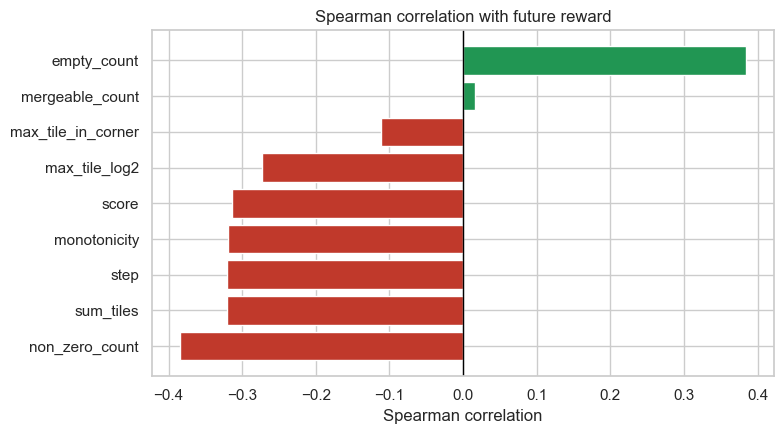

In [4]:
plt.figure(figsize=(8, 4.5))
plot_df = state_correlations.sort_values("spearman_corr")
colors = ["#c0392b" if value < 0 else "#219653" for value in plot_df["spearman_corr"]]
plt.barh(plot_df["feature"], plot_df["spearman_corr"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Spearman correlation with future reward")
plt.xlabel("Spearman correlation")
plt.ylabel("")
plt.tight_layout()
plt.show()

,feature,importance
0,sum_tiles,0.320
1,empty_count,0.143
2,non_zero_count,0.133
3,score,0.120
4,step,0.118
5,monotonicity,0.077
6,max_tile_in_corner,0.050
7,mergeable_count,0.023
8,max_tile_log2,0.016


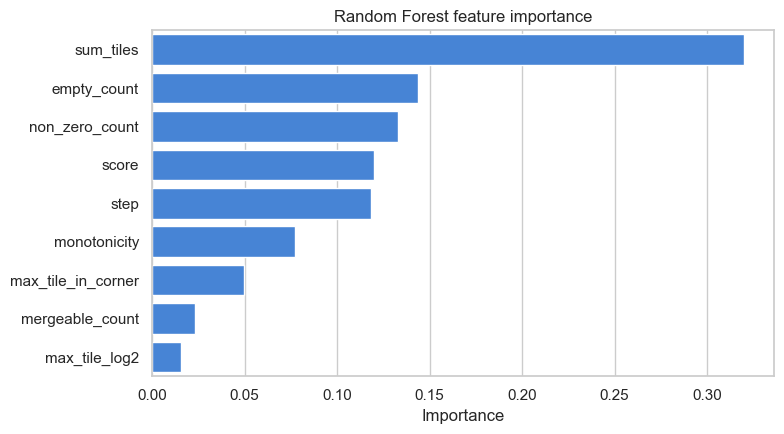

In [5]:
importance_view = state_importance.copy()
importance_view["importance"] = importance_view["importance"].round(3)
display(importance_view)

plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=state_importance,
    y="feature",
    x="importance",
    color="#2f80ed",
    order=state_importance.sort_values("importance", ascending=False)["feature"],
)
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Вывод.** Количество пустых клеток показывает наиболее сильную положительную связь с будущим reward. Признаки стадии игры (`score`, `step`, `sum_tiles`) имеют отрицательную корреляцию с target, потому что на поздних этапах игры остается меньше будущего score до финала. Feature importance также выделяет stage-related признаки и `empty_count`, что подтверждает важность свободного пространства на доске.

## 3. Сравнение агентов

Теперь перейдем от отдельных состояний к целым игровым сессиям. Основная метрика — итоговый score игры.

In [6]:
summary_view = agent_summary.copy()
numeric_cols = summary_view.select_dtypes(include="number").columns
summary_view[numeric_cols] = summary_view[numeric_cols].round(2)
display(summary_view)

,agent,n_games,mean_score,median_score,std_score,min_score,max_score,mean_max_tile,median_max_tile,mean_steps,median_steps,mean_score_ci_low,mean_score_ci_high
0,expectimax,3000,15400.51,15398.0,6279.56,2408,35648,1108.22,1024.0,826.23,841.0,15178.96,15618.96
1,heuristic,3000,4512.39,4232.0,1930.22,676,14060,351.77,256.0,310.22,298.0,4444.53,4580.54
2,random,3000,1006.07,960.0,508.15,88,3224,101.67,128.0,103.90,100.0,988.31,1024.52


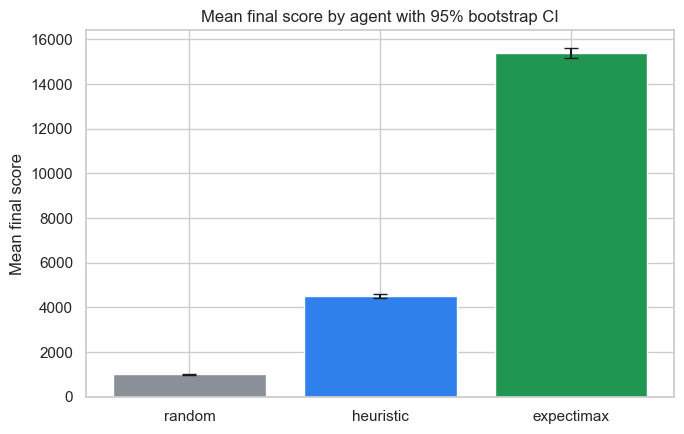

In [7]:
plot_summary = agent_summary.set_index("agent").reindex(AGENT_ORDER).reset_index()
yerr = np.vstack([
    plot_summary["mean_score"] - plot_summary["mean_score_ci_low"],
    plot_summary["mean_score_ci_high"] - plot_summary["mean_score"],
])

plt.figure(figsize=(7, 4.5))
plt.bar(
    plot_summary["agent"],
    plot_summary["mean_score"],
    yerr=yerr,
    capsize=5,
    color=[PALETTE[a] for a in plot_summary["agent"]],
)
plt.title("Mean final score by agent with 95% bootstrap CI")
plt.xlabel("")
plt.ylabel("Mean final score")
plt.tight_layout()
plt.show()

/var/folders/k_/clmzsj7x4wd3_j8cxbk4f_d80000gn/T/ipykernel_98422/1359166063.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


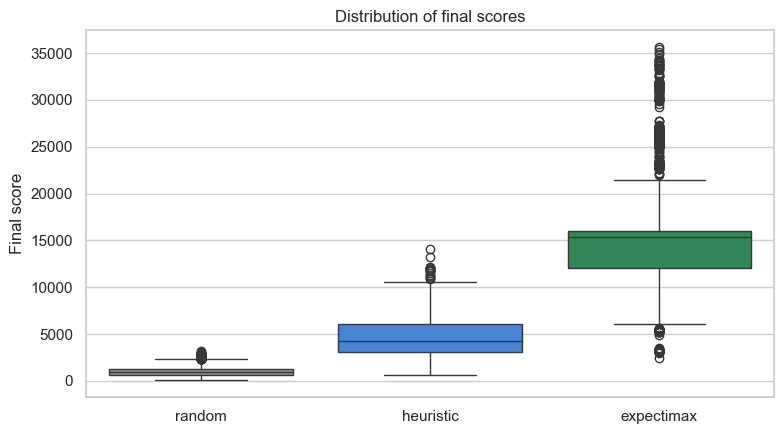

In [8]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(
    data=agent_games,
    x="agent",
    y="final_score",
    order=AGENT_ORDER,
    palette=PALETTE,
)
plt.title("Distribution of final scores")
plt.xlabel("")
plt.ylabel("Final score")
plt.tight_layout()
plt.show()

In [9]:
tests_view = pairwise_tests.copy()
for col in ["mean_score_a", "mean_score_b", "mean_score_diff_a_minus_b"]:
    tests_view[col] = tests_view[col].round(2)
tests_view["ttest_p_value"] = tests_view["ttest_p_value"].map(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")
tests_view["mannwhitney_p_value"] = tests_view["mannwhitney_p_value"].map(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")
display(tests_view)

,agent_a,agent_b,n_games_a,n_games_b,mean_score_a,mean_score_b,mean_score_diff_a_minus_b,ttest_p_value,mannwhitney_p_value
0,expectimax,heuristic,3000,3000,15400.51,4512.39,10888.13,< 0.001,< 0.001
1,expectimax,random,3000,3000,15400.51,1006.07,14394.45,< 0.001,< 0.001
2,heuristic,random,3000,3000,4512.39,1006.07,3506.32,< 0.001,< 0.001


**Вывод.** `expectimax` существенно превосходит `heuristic` и `random` по среднему итоговому score. Разница между всеми парами агентов статистически значима на уровне `p < 0.001`; при этом размер эффекта также велик, поэтому отличие заметно не только статистически, но и практически.

## 4. Funnel metrics

Достижение крупных плиток можно рассматривать как conversion event внутри игровой сессии. Для каждого агента посчитаем долю игр, достигших плиток 256, 512, 1024 и 2048.

In [10]:
funnel_view = session_funnel.copy()
funnel_view["conversion_rate"] = (100 * funnel_view["conversion_rate"]).round(2)
display(funnel_view)

,agent,milestone_tile,total_games,reached_games,conversion_rate
0,expectimax,256,3000,3000,100.00
1,expectimax,512,3000,2969,98.97
2,expectimax,1024,3000,2473,82.43
3,expectimax,2048,3000,518,17.27
4,heuristic,256,3000,2694,89.80
5,heuristic,512,3000,1222,40.73
6,heuristic,1024,3000,28,0.93
7,heuristic,2048,3000,0,0.00
8,random,256,3000,185,6.17
9,random,512,3000,0,0.00


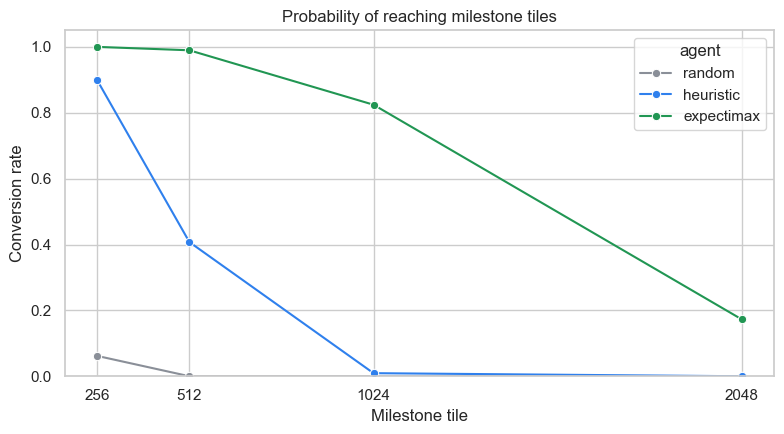

In [11]:
plt.figure(figsize=(8, 4.5))
sns.lineplot(
    data=session_funnel,
    x="milestone_tile",
    y="conversion_rate",
    hue="agent",
    hue_order=AGENT_ORDER,
    palette=PALETTE,
    marker="o",
)
plt.title("Probability of reaching milestone tiles")
plt.xlabel("Milestone tile")
plt.ylabel("Conversion rate")
plt.xticks([256, 512, 1024, 2048])
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Вывод.** `expectimax` почти всегда достигает 512 и часто достигает 1024, а 2048 появляется примерно в 17% игр. `heuristic` хорошо проходит ранние пороги, но почти не доходит до 1024. `random` практически не проходит дальше 256.

## 5. Survival analysis

Игру можно трактовать как сессию, а проигрыш — как churn. Survival curve показывает вероятность того, что игра все еще продолжается после заданного числа ходов.

In [12]:
display(session_summary.round(2))

,agent,n_sessions,expected_final_score,median_final_score,expected_session_length,median_session_length,mean_max_tile,median_max_tile
0,expectimax,3000,15400.51,15398.0,826.23,841.0,1108.22,1024.0
1,heuristic,3000,4512.39,4232.0,310.22,298.0,351.77,256.0
2,random,3000,1006.07,960.0,103.90,100.0,101.67,128.0


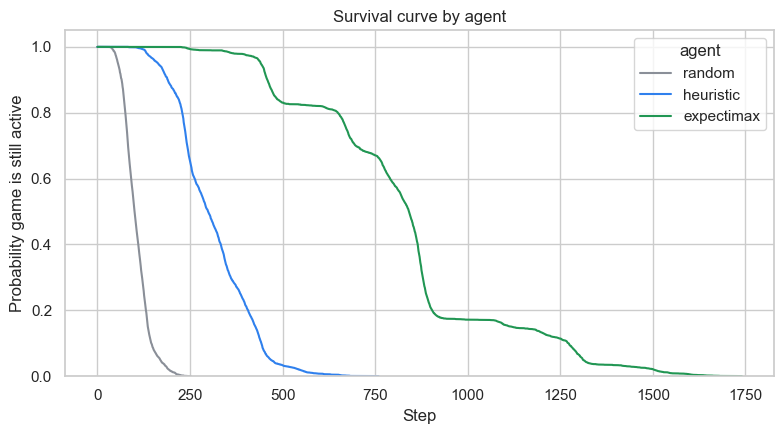

In [13]:
plt.figure(figsize=(8, 4.5))
sns.lineplot(
    data=survival_curve,
    x="step",
    y="survival_probability",
    hue="agent",
    hue_order=AGENT_ORDER,
    palette=PALETTE,
)
plt.title("Survival curve by agent")
plt.xlabel("Step")
plt.ylabel("Probability game is still active")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Вывод.** `expectimax` не только набирает больше score, но и значительно продлевает игровую сессию. Это видно и по среднему числу ходов, и по survival curve: стратегия дольше сохраняет доску в жизнеспособном состоянии.

## 6. Summary

- На уровне состояний доски важнейший положительный фактор будущего reward — количество пустых клеток.
- `expectimax` показывает лучший итоговый score и существенно превосходит остальные стратегии.
- Funnel analysis показывает, что `expectimax` намного чаще достигает плиток 1024 и 2048.
- Survival analysis подтверждает, что сильная стратегия не только набирает больше очков, но и продлевает игровую сессию.

Этот проект можно рассматривать как симуляцию аналитического сравнения продуктовых вариантов: разные AI-агенты выступают как варианты стратегии, игры — как пользовательские сессии, а score, conversion и survival — как метрики качества.